# **Trabajo Práctico Final: Proyecto Integrador** - Grupo

**Integrantes:**

* Gabriel Dannunzio
* Juan Manuel Etchehun
* Pablo Tapia
* Pablo Donato Nuñez

## **Descripción:**
El dataset a trabajar pertenece a un equipo de analistas de datos de una cadena de supermercado en USA durante el período de 3 años. El objetivo es realizar un Análisis Exploratorio de Datos (EDA) para identificar patrones de compra, analizar las ventas y extraer insights valiosos para la empresa.

**Dataset:** Supermarket_Sales

## **Objetivos:**

- Limpiar y preprocesar el dataset
- Obtener estadísticas descriptivas y analizarlas.
- Visualizar patrones
- Extraer conclusiones
- Presentar conclusiones con objetivo de potenciar el negocio
- La Visualización deberá presentar con PowerBI para explicitar la propuesta al negocio



## Preparación del entorno de trabajo→ Herramientas que usaremos

In [ ]:
# Librerías principales para análisis y manipulación de datos
import pandas as pd
import numpy as np

In [ ]:
# Librerías para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Herramientas auxiliares para limpieza de texto y manejo de rutas
import re
from pathlib import Path
from difflib import get_close_matches

In [ ]:
# Configuración para mostrar números con dos decimales
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# Estilo visual para los gráficos
sns.set_theme(style='whitegrid')

## 1. Carga del dataset

Primero cargamos el archivo crudo desde Google Drive.  
Como ya tenemos identificada la carpeta del proyecto, usamos la ruta directa al archivo `df_sales_crudo.csv`.

La base se carga en una variable llamada `df_raw`, porque representa el dataset original, antes de aplicar limpieza o transformaciones.

In [ ]:
# link del CSV de Drive
url = "https://drive.google.com/file/d/1iBIlQ42QQjsi17PYuhLx04ZEXUSoAFay/view?usp=sharing"

# Convertir link de Drive a descarga directa
file_id = url.split("/d/")[1].split("/")[0]
url_descarga = f"https://drive.google.com/uc?id={file_id}"

# Leer CSV
df_raw = pd.read_csv(url_descarga)

print("Dataset cargado correctamente")
print("Dimensión:", df_raw.shape)

df_raw.head()

Dataset cargado correctamente
Dimensión: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,NaN,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.20,2.52


## 2. Primera mirada general

Antes de tocar el dataset, revisamos tamaño, columnas y tipos de datos. Esto ayuda a detectar problemas de entrada.

In [ ]:
print('Filas y columnas', df_raw.shape)
df_raw.info()

Filas y columnas (9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9767 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9773 non-null   object 
 7   Segment        9771 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9761 non-null   object 
 10  State          9775 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9790 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9798 non-null   object 
 15  Sub-Category   9763 non-null   object 
 16  Product Name   9776 non-null   object 
 17  Sales          9994 non-

In [ ]:
df_raw.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,NaN,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.20,2.52
5,6,CA-2014-115812,2014-06-09 00:00:00,2014-06-14,Standard Class,BH-11710,NaN,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7,0.00,14.17
6,7,CA-2014-115812,2014-06-09 00:00:00,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.28,4,0.00,1.97
7,8,CA-2014-115812,2014-06-09 00:00:00,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6,0.20,90.72
8,9,CA-2014-115812,2014-06-09 00:00:00,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,0.20,5.78
9,10,CA-2014-115812,2014-06-09 00:00:00,2014-06-14,NaN,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,NaN,Belkin F5C206VTEL 6 Outlet Surge,114.9,5,0.00,34.47


### Diagnóstico de valores nulos y duplicados

In [ ]:
resumen_nulos = (
    df_raw.isna().sum()
    .to_frame('nulos')
    .assign(porcentaje=lambda x: (x['nulos'] / len(df_raw) * 100).round(2))
    .sort_values('nulos', ascending=False)
)

resumen_nulos

,nulos,porcentaje
City,233,2.33
Sub-Category,231,2.31
Ship Mode,227,2.27
Segment,223,2.23
Customer Name,221,2.21
State,219,2.19
Product Name,218,2.18
Region,204,2.04
Category,196,1.96
Ship Date,0,0.00


In [ ]:
print('Filas duplicadas exactas:', df_raw.duplicated().sum())

Filas duplicadas exactas: 0


### Observación inicial

En esta primera revisión ya aparecen algunas cosas para trabajar:

- `Sales` y `Quantity` figuran como texto, aunque deberían ser numéricas.
- `Order Date` y `Ship Date` todavía no están como fechas.
- Hay nulos en columnas como `City`, `State`, `Region`, `Category`, `Segment`, `Ship Mode`, etc.
- `Postal Code` aparece como número, pero en realidad es un código/identificador geográfico.
- Hay errores de tipeo en categorías de texto, por ejemplo en `Ship Mode`, `Segment` y `Category`.

## 3. Revisión de problemas puntuales

Ahora miramos algunos problemas concretos antes de limpiarlos. Esto sirve para justificar el preprocesamiento.

In [ ]:
# Revisamos si algunas columnas importantes pueden convertirse al tipo de dato esperado.
# Sales y Quantity deberían ser numéricas.
# Order Date y Ship Date deberían ser fechas.

problemas_conversion = pd.DataFrame({
    'columna': ['Sales', 'Quantity', 'Order Date', 'Ship Date'],
    'valores_problematicos': [
        pd.to_numeric(df_raw['Sales'], errors='coerce').isna().sum(),
        pd.to_numeric(df_raw['Quantity'], errors='coerce').isna().sum(),
        pd.to_datetime(df_raw['Order Date'], errors='coerce').isna().sum(),
        pd.to_datetime(df_raw['Ship Date'], errors='coerce').isna().sum()
    ]
})

problemas_conversion

,columna,valores_problematicos
0,Sales,50
1,Quantity,50
2,Order Date,30
3,Ship Date,0


In [ ]:
# Mostramos ejemplos concretos de valores que no pueden convertirse al tipo esperado.
# Esto ayuda a entender qué errores existen antes de realizar la limpieza.

print('Ejemplos problemáticos en Sales:')
display(df_raw.loc[pd.to_numeric(df_raw['Sales'], errors='coerce').isna(), ['Sales']].drop_duplicates().head())

print('Ejemplos problemáticos en Quantity:')
display(df_raw.loc[pd.to_numeric(df_raw['Quantity'], errors='coerce').isna(), ['Quantity']].drop_duplicates().head())

print('Ejemplos problemáticos en Order Date:')
display(df_raw.loc[pd.to_datetime(df_raw['Order Date'], errors='coerce').isna(), ['Order Date']].drop_duplicates().head())


Ejemplos problemáticos en Sales:


,Sales
43,Corrupted_Sale


Ejemplos problemáticos en Quantity:


,Quantity
15,Invalid_Qty


Ejemplos problemáticos en Order Date:


,Order Date
629,DATE_ERROR_FORMAT


### Caso especial: Postal Code

`Postal Code` parece numérico, pero no lo es en sentido analítico. No tiene sentido calcular un promedio de códigos postales.  
Además, en Estados Unidos algunos códigos pueden empezar con cero, y si se guardan como número se pierde ese cero inicial.

In [ ]:
# Postal Code se analiza como identificador geográfico, no como número.
# Revisamos la longitud de los códigos para detectar casos que pudieron perder un cero inicial.


longitud_postal_antes = df_raw['Postal Code'].astype(str).str.len().value_counts().sort_index()
longitud_postal_antes

,count
Postal Code,
4,449
5,9545


In [ ]:
# Mostramos algunos ejemplos de códigos de 4 dígitos antes de corregirlos.
postal_4_digitos = df_raw.loc[df_raw['Postal Code'].astype(str).str.len() == 4, 'Postal Code'].head(10)
postal_4_digitos

,Postal Code
185,6824
197,7090
267,7960
298,7109
299,7109
300,7109
301,7109
302,7109
306,8701
307,8701


## 4. Limpieza y transformación

Creamos una copia para no modificar el dataset original. El criterio será:

1. convertir ventas, cantidades y fechas;
2. tratar `Postal Code` como texto de 5 caracteres;
3. normalizar algunas columnas categóricas;
4. eliminar solo filas con problemas en campos críticos;
5. completar nulos categóricos como `Sin dato`, sin inventar información.

In [ ]:
df = df_raw.copy()

# Conversiones numéricas
# Si aparece algo como Corrupted_Sale o Invalid_Qty, lo pasamos a NaN para tratarlo después.
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# Conversiones de fecha
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Postal Code como texto. zfill(5) agrega ceros a la izquierda cuando corresponde.
df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)

# Muestro los tipos de datos después de la conversión
print(df[['Sales', 'Quantity', 'Order Date', 'Ship Date', 'Postal Code']].dtypes)

Sales                 float64
Quantity              float64
Order Date     datetime64[ns]
Ship Date      datetime64[ns]
Postal Code            object
dtype: object


In [ ]:
# Verificación de Postal Code después del ajuste
print(df['Postal Code'].astype(str).str.len().value_counts().sort_index())
df[['Postal Code']].head()

Postal Code
5    9994
Name: count, dtype: int64


,Postal Code
0,42420
1,42420
2,90036
3,33311
4,33311


In [ ]:
# Convertimos las columnas numéricas.
# Los valores inválidos se transforman en NaN para poder tratarlos después.
# errors='coerce' transforma los valores corruptos en NaN así no rompe código

df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

### Normalización de variables categóricas

En `Ship Mode`, `Segment` y `Category` hay errores de tipeo. Para no hacer un diccionario enorme a mano, uso una función simple que compara contra valores válidos esperados.

No es una solución perfecta para producción, pero para este análisis sirve porque conocemos las categorías correctas

In [ ]:
# Función auxiliar para normalizar textos categóricos.
# Corrige espacios, mayúsculas/minúsculas y algunos errores de tipeo simples
# comparando contra una lista de valores válidos.

def normalizar_texto(valor, valores_validos, cutoff=0.70):
    if pd.isna(valor):
        return np.nan

    texto = str(valor).lower().strip()
    texto = re.sub(r'\s+', ' ', texto)

    valores_norm = [v.lower() for v in valores_validos]

    if texto in valores_norm:
        return valores_validos[valores_norm.index(texto)]

    parecido = get_close_matches(texto, valores_norm, n=1, cutoff=cutoff)
    if parecido:
        return valores_validos[valores_norm.index(parecido[0])]

    return texto.title()

In [ ]:
# Definimos los valores correctos esperados para algunas columnas categóricas.
# Luego revisamos cómo aparecen esos valores en la base cruda antes de limpiarlos.


# Valores válidos esperados según el dataset original de ventas
ship_validos = ['Standard Class', 'Second Class', 'First Class', 'Same Day']
segment_validos = ['Consumer', 'Corporate', 'Home Office']
category_validos = ['Furniture', 'Office Supplies', 'Technology']

# Antes
display(df_raw['Ship Mode'].value_counts(dropna=False).head(15).to_frame('antes_ship_mode'))
display(df_raw['Segment'].value_counts(dropna=False).head(15).to_frame('antes_segment'))
display(df_raw['Category'].value_counts(dropna=False).head(15).to_frame('antes_category'))

,antes_ship_mode
Ship Mode,
Standard Class,5804
Second Class,1894
First Class,1478
Same Day,522
NaN,227
Sceond Class,3
StandardClass,3
Standadr Class,2
Fisrt Class,2


,antes_segment
Segment,
Consumer,5046
Corporate,2932
Home Office,1724
NaN,223
CConsumer,4
Cnosumer,4
Conumer,3
Corproate,3
Home Ofice,3


,antes_category
Category,
Office Supplies,5868
Furniture,2061
Technology,1804
NaN,196
Furniutre,4
Ofice Supplies,4
Office Suppies,3
Office SSupplies,2
echnology,2


In [ ]:
# Aplicamos la función de normalización a columnas categóricas.
# Luego revisamos nuevamente los valores para comparar el antes y el después.


df['Ship Mode'] = df['Ship Mode'].apply(lambda x: normalizar_texto(x, ship_validos, cutoff=0.70))
df['Segment'] = df['Segment'].apply(lambda x: normalizar_texto(x, segment_validos, cutoff=0.70))
df['Category'] = df['Category'].apply(lambda x: normalizar_texto(x, category_validos, cutoff=0.68))

# Después
display(df['Ship Mode'].value_counts(dropna=False).to_frame('despues_ship_mode'))
display(df['Segment'].value_counts(dropna=False).to_frame('despues_segment'))
display(df['Category'].value_counts(dropna=False).to_frame('despues_category'))

,despues_ship_mode
Ship Mode,
Standard Class,5844
Second Class,1907
First Class,1491
Same Day,525
NaN,227


,despues_segment
Segment,
Consumer,5077
Corporate,2950
Home Office,1744
NaN,223


,despues_category
Category,
Office Supplies,5906
Furniture,2081
Technology,1811
NaN,196


### Tratamiento de nulos

Para este primer avance vamos a usar un criterio simple:

- si faltan `Sales`, `Quantity`, `Order Date` o `Ship Date`, la fila no sirve para análisis principal de ventas y se elimina;
- si falta un dato categórico, no lo inventamos: lo marcamos como `Sin dato`.

Esto permite conservar la mayoría de los registros sin generar datos falsos.

In [ ]:
# Eliminamos filas con valores faltantes en campos críticos para el análisis.
# No eliminamos cualquier nulo del dataset, solo aquellos que afectan directamente
# las ventas, cantidades, fechas o identificadores principales.
# Además, medimos cuántas filas se pierden para evaluar el impacto de esta decisión.

filas_antes = len(df)

campos_criticos = ['Sales', 'Quantity', 'Order Date', 'Ship Date', 'Order ID', 'Product ID']
df_clean = df.dropna(subset=campos_criticos).copy()

filas_despues = len(df_clean)
print('Filas antes:', filas_antes)
print('Filas después de quitar críticos nulos:', filas_despues)
print('Filas eliminadas:', filas_antes - filas_despues)
print('Porcentaje eliminado:', round((filas_antes - filas_despues) / filas_antes * 100, 2), '%')

Filas antes: 9994
Filas después de quitar críticos nulos: 9864
Filas eliminadas: 130
Porcentaje eliminado: 1.3 %


In [ ]:

# En esta etapa limpiamos las columnas de texto:
# - eliminamos espacios al inicio y al final;
# - reemplazamos valores faltantes por "Sin dato";
# - convertimos Quantity a entero porque representa unidades vendidas.
# Finalmente revisamos si todavía quedan valores nulos en la base.

# Limpiamos espacios en columnas de texto y completamos nulos como Sin dato
columnas_texto = df_clean.select_dtypes(include=['object', 'string']).columns

for col in columnas_texto:
    df_clean[col] = df_clean[col].astype('string').str.strip()
    df_clean[col] = df_clean[col].fillna('Sin dato')

# Quantity debería ser entera porque representa unidades
# Usamos Int64 por seguridad, aunque luego no deberían quedar nulos.
df_clean['Quantity'] = df_clean['Quantity'].astype('Int64')

print('Nulos restantes:', df_clean.isna().sum().sum())
df_clean.head()

Nulos restantes: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Sin dato,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


## 5. Variables derivadas

Agregamos algunas columnas útiles para el análisis:

- días de envío;
- año;
- mes;
- año-mes;
- margen aproximado de ganancia sobre ventas.

In [ ]:
# Síntesis

# Creamos variables derivadas para enriquecer el análisis:
# - Shipping Days mide la diferencia entre fecha de envío y fecha de pedido.
# - Year, Month y Order Year-Month permiten analizar la evolución temporal.
# - Profit Margin calcula la rentabilidad relativa de cada venta.
# También revisamos los valores mínimos y máximos de Shipping Days para detectar fechas inconsistentes.

df_clean['Shipping Days'] = (df_clean['Ship Date'] - df_clean['Order Date']).dt.days

df_clean['Year'] = df_clean['Order Date'].dt.year
df_clean['Month'] = df_clean['Order Date'].dt.month
df_clean['Month Name'] = df_clean['Order Date'].dt.month_name()
df_clean['Order Year-Month'] = df_clean['Order Date'].dt.to_period('M').astype(str)

# Profit Margin: ganancia / ventas. Si Sales fuera 0, evitamos división por cero.
df_clean['Profit Margin'] = np.where(
    df_clean['Sales'] != 0,
    df_clean['Profit'] / df_clean['Sales'],
    np.nan
)

# Control de posibles fechas raras
print('Shipping Days mínimos y máximos:')
print(df_clean['Shipping Days'].agg(['min', 'max']))

df_clean[['Order Date', 'Ship Date', 'Shipping Days', 'Year', 'Month', 'Order Year-Month', 'Profit Margin']].head()

Shipping Days mínimos y máximos:
min    0
max    7
Name: Shipping Days, dtype: int64


,Order Date,Ship Date,Shipping Days,Year,Month,Order Year-Month,Profit Margin
0,2016-11-08,2016-11-11,3,2016,11,2016-11,0.16
1,2016-11-08,2016-11-11,3,2016,11,2016-11,0.30
2,2016-06-12,2016-06-16,4,2016,6,2016-06,0.47
3,2015-10-11,2015-10-18,7,2015,10,2015-10,-0.40
4,2015-10-11,2015-10-18,7,2015,10,2015-10,0.11


In [ ]:
# Si apareciera algún envío con días negativos, se puede revisar aparte.
# En este caso lo dejamos chequeado. Por el caso de que aparezcan casos raros
# Inconsistencia→ porque la fecha de envío no debería ser anterior
# a la fecha del pedido.

df_clean[df_clean['Shipping Days'] < 0].head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Shipping Days,Year,Month,Month Name,Order Year-Month,Profit Margin


## 6. Dataset limpio para análisis y visualización

En esta etapa generamos una versión final del dataset limpio, preparada para ser utilizada posteriormente en herramientas de visualización como **Power BI** o **Looker Studio**.

Antes de exportar el archivo, estandarizamos la cantidad de decimales en las columnas numéricas principales. Esto permite trabajar con valores más consistentes, facilita la lectura de los datos y evita diferencias innecesarias al momento de generar gráficos, métricas o indicadores.

Además, se recomienda que al importar el archivo en Power BI, la columna Postal Code sea tratada como texto, ya que no representa un valor numérico para cálculos, sino un identificador geográfico.

In [ ]:
# Definimos la cantidad de decimales que queremos conservar
# en las columnas numéricas principales del dataset.
# Esto permite estandarizar los valores antes de exportarlos.

ROUNDING_CONFIG = {
    "Sales": 2,
    "Profit": 2,
    "Discount": 4,
    "Profit Margin": 4
}

# Aplicamos el redondeo sobre el dataset limpio.
# Cada columna se ajusta según la cantidad de decimales definida arriba.
df_clean = df_clean.round(ROUNDING_CONFIG)

In [ ]:
# Exportamos el dataset limpio en formato Excel.
# El archivo se genera en el entorno temporal de Colab
# y luego se descarga automáticamente a la PC.

from google.colab import files

nombre_archivo = "df_sales_limpio_para_powerbi.xlsx"

df_clean.to_excel(nombre_archivo, index=False)

files.download(nombre_archivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Estadísticas descriptivas

Ahora analizamos variables numéricas principales. Esto permite ver magnitudes, dispersión y posibles valores extremos.

In [ ]:
# Seleccionamos las variables numéricas más relevantes para el análisis.
# Con describe() obtenemos medidas resumen como promedio, mínimo, máximo,
# cuartiles y desviación estándar. La .T se usa para leer la tabla más fácilmente.


columnas_numericas = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days', 'Profit Margin']
df_clean[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,9864.00,230.27,622.92,0.44,17.34,54.86,210.10,22638.48
Quantity,9864.00,3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,9864.00,0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,9864.00,28.65,234.51,-6599.98,1.73,8.67,29.37,8399.98
Shipping Days,9864.00,3.96,1.75,0.00,3.00,4.00,5.00,7.00
Profit Margin,9864.00,0.12,0.47,-2.75,0.07,0.27,0.36,0.50


In [ ]:

# Sintesis:

# Calculamos percentiles para analizar la distribución de las variables principales.
# Esto nos ayuda a identificar valores típicos, extremos y posibles outliers.

# Miramos algunos percentiles para detectar valores extremos sin eliminarlos automáticamente.
percentiles = df_clean[['Sales', 'Profit', 'Quantity', 'Discount']].quantile([0.01, 0.05, 0.50, 0.95, 0.99])
percentiles

,Sales,Profit,Quantity,Discount
0.01,2.30,-319.58,1.00,0.00
0.05,4.98,-53.24,1.00,0.00
0.50,54.86,8.67,3.00,0.20
0.95,959.61,170.31,8.00,0.70
0.99,2489.13,581.17,11.00,0.80


### Lectura inicial de las estadísticas

Se observa que `Sales` y `Profit` tienen mucha dispersión. Hay ventas de bajo monto y algunas operaciones muy grandes.  
También hay ganancias negativas, lo cual no necesariamente es un error: puede indicar descuentos agresivos, costos altos o productos poco rentables.

## 8. Análisis por categoría

Primero miramos ventas y ganancias por categoría. Esto ayuda a entender qué líneas del negocio aportan más facturación y rentabilidad.

In [ ]:

# Agrupamos los datos por categoría para comparar ventas, ganancias,
# unidades vendidas y cantidad de operaciones por cada grupo de productos.

resumen_categoria = (
    df_clean.groupby('Category')
    .agg(
        ventas_totales=('Sales', 'sum'),
        ganancia_total=('Profit', 'sum'),
        cantidad_vendida=('Quantity', 'sum'),
        operaciones=('Order ID', 'nunique')
    )
    .sort_values('ventas_totales', ascending=False)
)

resumen_categoria

,ventas_totales,ganancia_total,cantidad_vendida,operaciones
Category,,,,
Technology,803592.53,137998.24,6704,1505
Furniture,716409.05,17390.65,7790,1723
Office Supplies,702314.73,119472.92,22222,3658
Sin dato,49044.60,7716.34,698,190


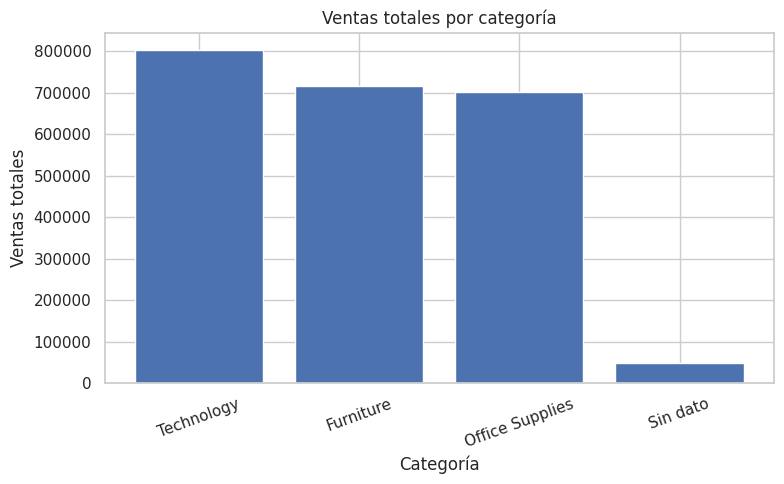

In [ ]:
# Convertimos el resumen en una tabla común para poder graficarlo.
# Luego hacemos un gráfico de barras para comparar visualmente
# las ventas totales de cada categoría.


plot_data = resumen_categoria.reset_index()
plt.figure(figsize=(8,5))
plt.bar(plot_data['Category'], plot_data['ventas_totales'])
plt.title('Ventas totales por categoría')
plt.xlabel('Categoría')
plt.ylabel('Ventas totales')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

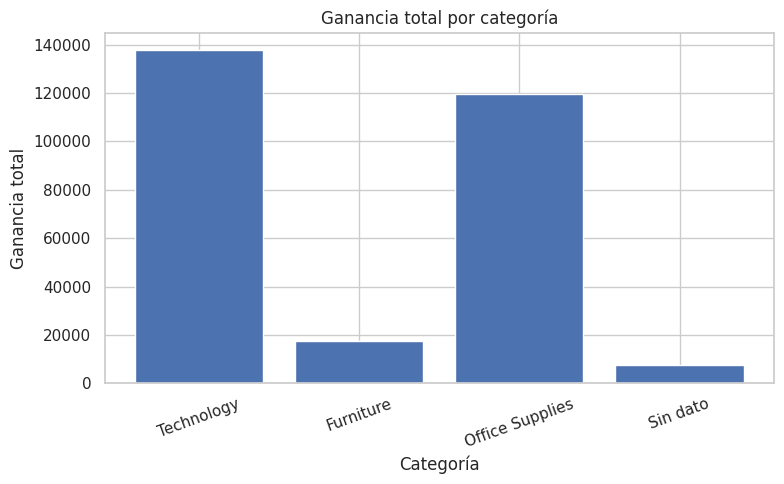

In [ ]:
# Graficamos la ganancia total por categoría.
# Este gráfico permite comparar la rentabilidad de cada categoría,
# no solo el volumen de ventas.


plot_data = resumen_categoria.reset_index()
plt.figure(figsize=(8,5))
plt.bar(plot_data['Category'], plot_data['ganancia_total'])
plt.title('Ganancia total por categoría')
plt.xlabel('Categoría')
plt.ylabel('Ganancia total')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Lectura a primera vista: una categoría puede vender mucho, pero no necesariamente ser la más rentable. Por eso conviene mirar ventas y profit juntos.

## 9. Análisis por subcategoría

Bajamos un nivel más para detectar subcategorías que generan mucho ingreso y otras que pueden estar perjudicando el margen


In [ ]:
# Agrupamos los datos por subcategoría para analizar con mayor detalle
# qué tipos de productos generan más ventas, ganancias y unidades vendidas.
# Luego ordenamos por ventas totales y mostramos las 10 subcategorías principales.


resumen_subcategoria = (
    df_clean.groupby('Sub-Category')
    .agg(
        ventas_totales=('Sales', 'sum'),
        ganancia_total=('Profit', 'sum'),
        cantidad_vendida=('Quantity', 'sum')
    )
    .sort_values('ventas_totales', ascending=False)
)

resumen_subcategoria.head(10)

,ventas_totales,ganancia_total,cantidad_vendida
Sub-Category,,,
Chairs,320516.23,25959.75,2281
Phones,315661.39,42994.60,3113
Storage,216019.57,20555.22,3068
Tables,198714.75,-17424.50,1193
Binders,189767.68,25063.23,5735
Machines,180628.00,1927.46,428
Accessories,163302.27,41036.62,2873
Copiers,148528.03,55167.89,232
Bookcases,112166.77,-3593.11,851


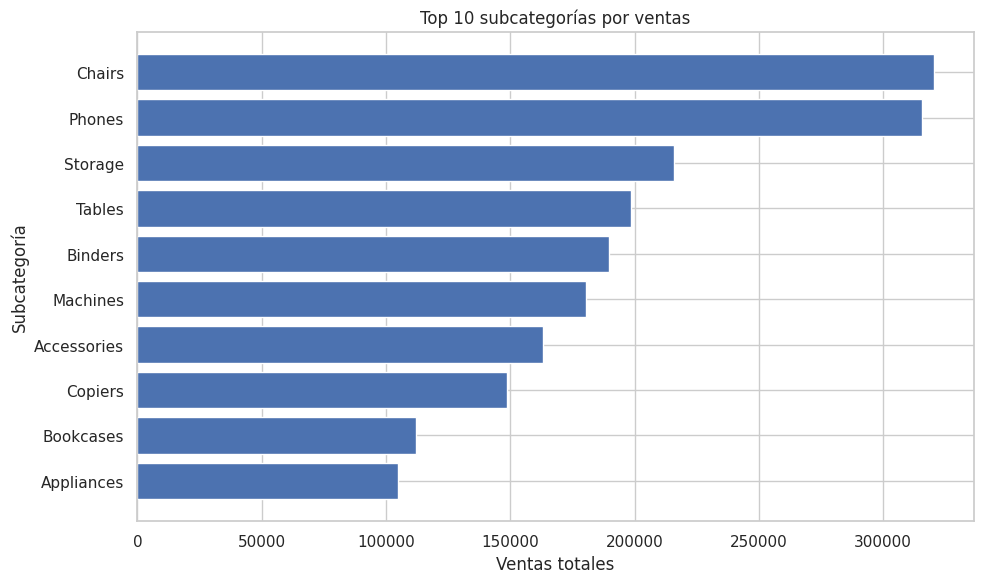

In [ ]:
# Tomamos las 10 subcategorías con mayor venta y las graficamos.
# Usamos barras horizontales para mejorar la lectura de los nombres
# y ordenamos visualmente de mayor a menor.

# Visualizar las subcategorías más relevantes por facturación (ergo ingresos)

top_subcat_ventas = resumen_subcategoria.head(10).reset_index()

plt.figure(figsize=(10,6))
plt.barh(top_subcat_ventas['Sub-Category'], top_subcat_ventas['ventas_totales'])
plt.title('Top 10 subcategorías por ventas')
plt.xlabel('Ventas totales')
plt.ylabel('Subcategoría')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Ordenamos las subcategorías por ganancia total de menor a mayor.
# Así identificamos las 10 subcategorías con peor resultado económico.

peores_subcat_profit = resumen_subcategoria.sort_values('ganancia_total').head(10).reset_index()
peores_subcat_profit

,Sub-Category,ventas_totales,ganancia_total,cantidad_vendida
0,Tables,198714.75,-17424.50,1193
1,Bookcases,112166.77,-3593.11,851
2,Supplies,45647.66,-988.35,633
3,Fasteners,2962.41,928.86,888
4,Machines,180628.00,1927.46,428
5,Labels,12351.15,5484.72,1367
6,Art,26459.90,6343.15,2893
7,Envelopes,16006.94,6782.95,887
8,Sin dato,52709.58,8417.82,840
9,Furnishings,89278.14,12906.75,3454


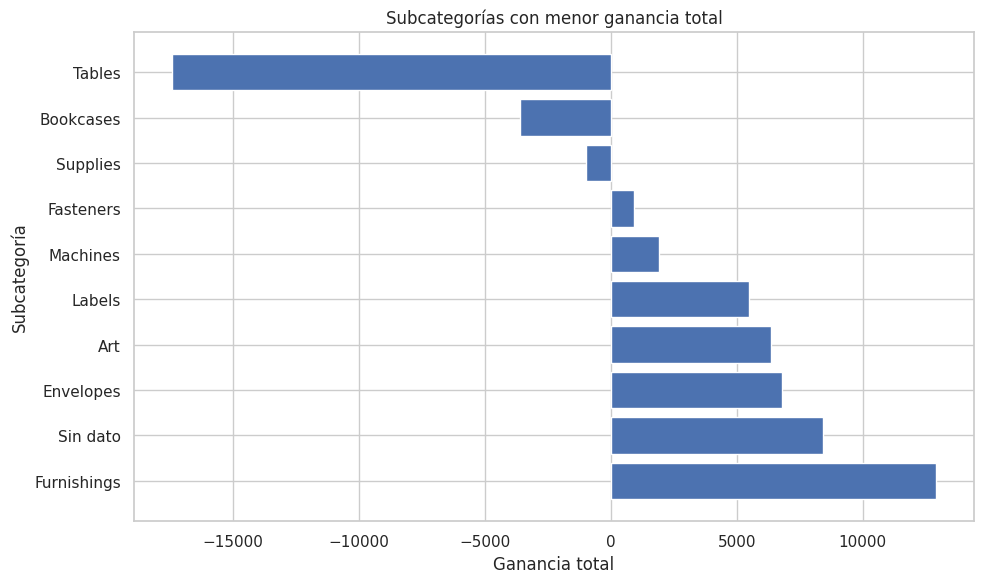

In [ ]:
# Graficamos las subcategorías con menor ganancia total.
# Esto permite identificar visualmente productos o líneas que pueden estar generando baja rentabilidad o pérdidas.


plt.figure(figsize=(10,6))
plt.barh(peores_subcat_profit['Sub-Category'], peores_subcat_profit['ganancia_total'])
plt.title('Subcategorías con menor ganancia total')
plt.xlabel('Ganancia total')
plt.ylabel('Subcategoría')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Este gráfico es útil porque muestra dónde puede haber problemas de rentabilidad. No alcanza con vender mucho: algunas subcategorías pueden estar generando pérdida.

## 10. Análisis por región y segmento

Ahora miramos el negocio por ubicación y tipo de cliente.


In [ ]:
# Agrupamos los datos por región para analizar el desempeño geográfico.
# Calculamos ventas, ganancias y cantidad de órdenes únicas por cada región.


resumen_region = (
    df_clean.groupby('Region')
    .agg(
        ventas_totales=('Sales', 'sum'),
        ganancia_total=('Profit', 'sum'),
        operaciones=('Order ID', 'nunique')
    )
    .sort_values('ventas_totales', ascending=False)
)

resumen_region

,ventas_totales,ganancia_total,operaciones
Region,,,
West,708155.64,105680.90,1580
East,647812.03,87425.51,1367
Central,490819.51,39095.07,1153
South,382350.88,45693.26,814
Sin dato,42222.85,4683.41,199


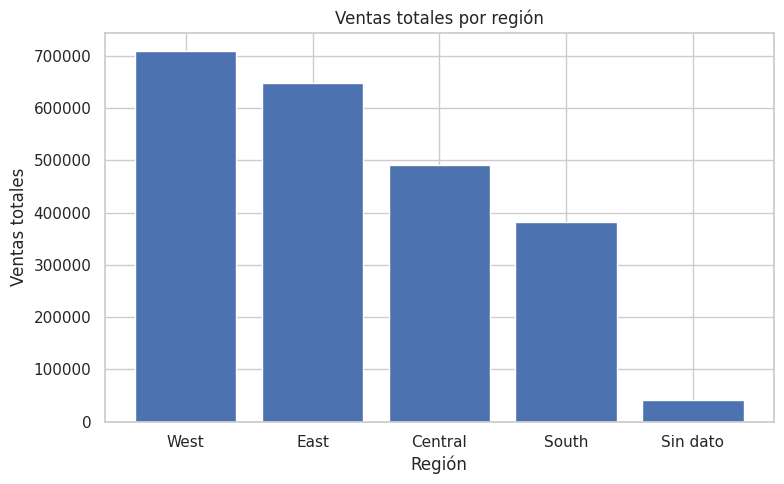

In [ ]:
# Graficamos las ventas totales por región.
# Esto permite comparar visualmente qué zonas concentran mayor facturación.


plot_data = resumen_region.reset_index()
plt.figure(figsize=(8,5))
plt.bar(plot_data['Region'], plot_data['ventas_totales'])
plt.title('Ventas totales por región')
plt.xlabel('Región')
plt.ylabel('Ventas totales')
plt.tight_layout()
plt.show()

In [ ]:
# Agrupamos los datos por segmento de cliente para comparar su desempeño.
# Calculamos ventas totales, ganancia total, cantidad de órdenes únicas
# y venta promedio por registro.

resumen_segmento = (
    df_clean.groupby('Segment')
    .agg(
        ventas_totales=('Sales', 'sum'),
        ganancia_total=('Profit', 'sum'),
        operaciones=('Order ID', 'nunique'),
        ticket_promedio=('Sales', 'mean')
    )
    .sort_values('ventas_totales', ascending=False)
)

resumen_segmento

,ventas_totales,ganancia_total,operaciones,ticket_promedio
Segment,,,,
Consumer,1117630.07,127256.95,2533,223.17
Corporate,684946.31,90161.85,1489,234.57
Home Office,418696.44,57622.00,887,243.85
Sin dato,50088.09,7537.35,215,228.71


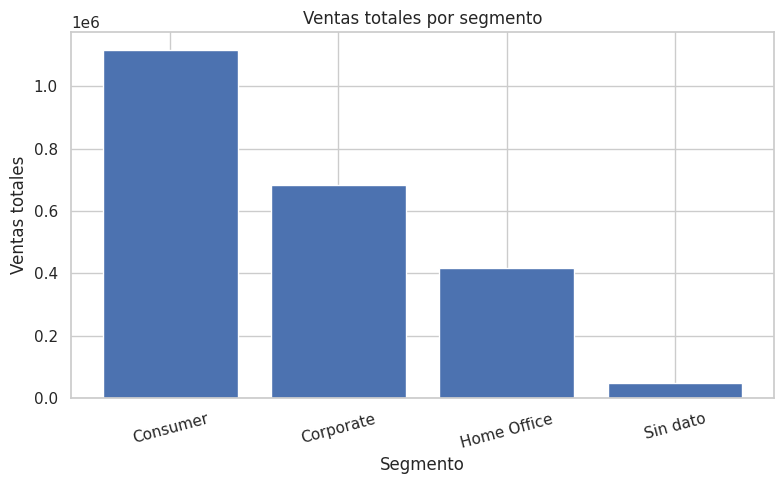

In [ ]:
# Graficamos las ventas totales por segmento de cliente.
# Esto nos permite comparar visualmente qué segmento aporta más facturación.


plot_data = resumen_segmento.reset_index()
plt.figure(figsize=(8,5))
plt.bar(plot_data['Segment'], plot_data['ventas_totales'])
plt.title('Ventas totales por segmento')
plt.xlabel('Segmento')
plt.ylabel('Ventas totales')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 11. Evolución mensual de ventas

Como tenemos fechas, podemos ver cómo cambian las ventas a lo largo del tiempo.

In [ ]:
# Agrupamos los datos por año-mes del pedido para analizar la evolución temporal.
# Calculamos ventas, ganancias y cantidad de órdenes únicas por cada mes.
# Luego ordenamos cronológicamente para poder graficar correctamente la serie.


ventas_mensuales = (
    df_clean.groupby('Order Year-Month')
    .agg(
        ventas_totales=('Sales', 'sum'),
        ganancia_total=('Profit', 'sum'),
        operaciones=('Order ID', 'nunique')
    )
    .reset_index()
    .sort_values('Order Year-Month')
)

ventas_mensuales.head()

,Order Year-Month,ventas_totales,ganancia_total,operaciones
0,2014-01,14236.90,2450.17,32
1,2014-02,4519.92,862.30,28
2,2014-03,55321.46,452.69,70
3,2014-04,28295.35,3488.83,66
4,2014-05,23422.97,2716.19,68


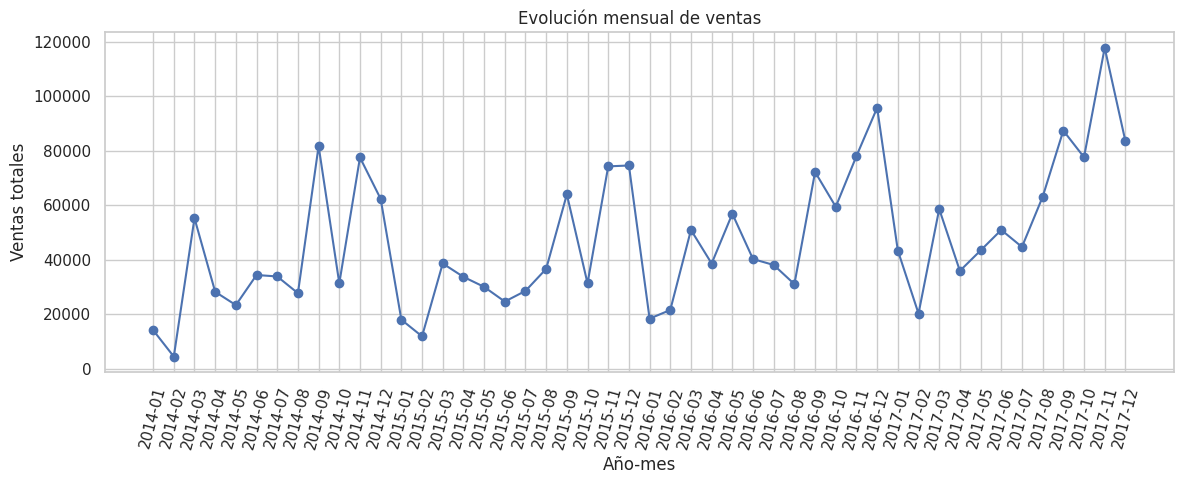

In [ ]:
# Graficamos la evolución mensual de ventas.
# Usamos un gráfico de línea porque queremos observar cambios en el tiempo,
# como tendencias, picos o caídas en determinados meses.

plt.figure(figsize=(12,5))
plt.plot(ventas_mensuales['Order Year-Month'], ventas_mensuales['ventas_totales'], marker='o')
plt.title('Evolución mensual de ventas')
plt.xlabel('Año-mes')
plt.ylabel('Ventas totales')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## 12. Descuentos y rentabilidad

Los descuentos pueden ayudar a vender, pero también pueden afectar la ganancia. Revisamos la relación entre descuento y profit.

In [ ]:
# Agrupamos los datos por nivel de descuento para analizar su relación
# con las ventas, la ganancia y la cantidad de registros.
# Esto ayuda a observar si los descuentos altos se asocian con menor rentabilidad.



resumen_descuento = (
    df_clean.groupby('Discount')
    .agg(
        ventas_totales=('Sales', 'sum'),
        ganancia_total=('Profit', 'sum'),
        operaciones=('Order ID', 'count')
    )
    .reset_index()
    .sort_values('Discount')
)

resumen_descuento

,Discount,ventas_totales,ganancia_total,operaciones
0,0.00,1072166.53,316342.43,4737
1,0.10,53511.06,8886.17,93
2,0.15,26754.53,1437.89,50
3,0.20,760509.45,89586.74,3612
4,0.30,102867.39,-10303.41,224
5,0.32,14493.45,-2391.16,27
6,0.40,113022.95,-22206.69,200
7,0.45,5484.98,-2493.12,11
8,0.50,58918.53,-20506.49,66
9,0.60,6636.92,-5942.49,137


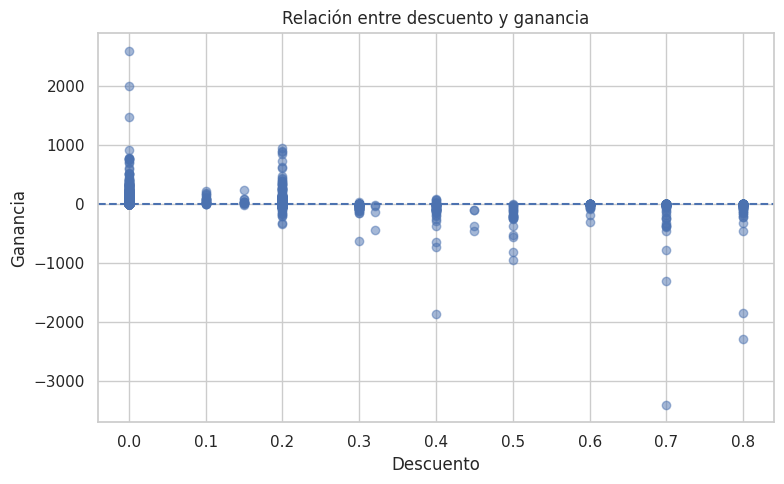

In [ ]:
# Tomamos una muestra para que el gráfico no quede sobrecargado.
# Luego graficamos la relación entre descuento y ganancia.
# La línea horizontal en cero ayuda a distinguir operaciones con ganancia y con pérdida.


muestra = df_clean.sample(min(2500, len(df_clean)), random_state=42)
plt.figure(figsize=(8,5))
plt.scatter(muestra['Discount'], muestra['Profit'], alpha=0.5)
plt.axhline(0, linestyle='--')
plt.title('Relación entre descuento y ganancia')
plt.xlabel('Descuento')
plt.ylabel('Ganancia')
plt.tight_layout()
plt.show()

## 13. Tiempo de envío

El campo `Shipping Days` permite ver la demora entre la fecha de pedido y la fecha de envío.

In [ ]:
# Agrupamos los datos por modo de envío para comparar tiempos de entrega.
# Calculamos demora promedio, demora mediana y cantidad de registros por cada modalidad.
# Luego ordenamos desde el modo con menor demora promedio al de mayor demora.


resumen_envio = (
    df_clean.groupby('Ship Mode')
    .agg(
        demora_promedio=('Shipping Days', 'mean'),
        demora_mediana=('Shipping Days', 'median'),
        operaciones=('Order ID', 'count')
    )
    .sort_values('demora_promedio')
)

resumen_envio

,demora_promedio,demora_mediana,operaciones
Ship Mode,,,
Same Day,0.05,0.00,517
First Class,2.18,2.00,1472
Second Class,3.24,3.00,1888
Sin dato,3.73,4.00,224
Standard Class,5.01,5.00,5763


/tmp/ipykernel_7059/755199894.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_box, labels=orden_ship)


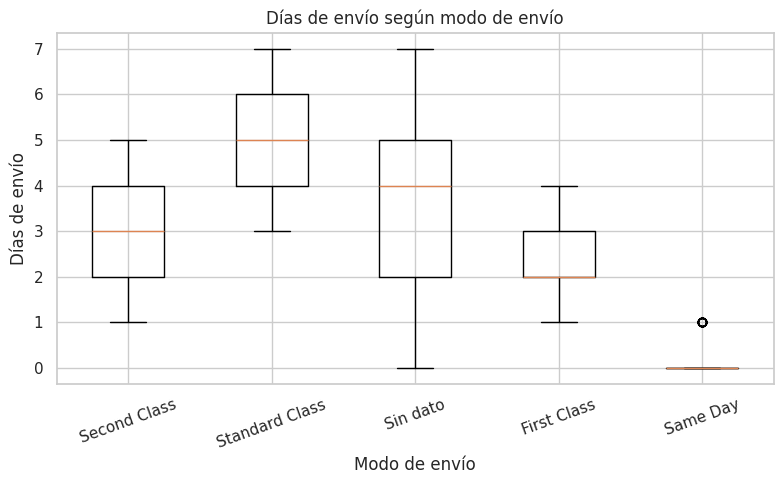

In [ ]:
# Creamos un boxplot para comparar la distribución de los días de envío
# según cada modo de envío. Este gráfico permite observar medianas,
# dispersión y posibles valores atípicos.


orden_ship = df_clean['Ship Mode'].dropna().unique()
datos_box = [df_clean.loc[df_clean['Ship Mode'] == modo, 'Shipping Days'] for modo in orden_ship]

plt.figure(figsize=(8,5))
plt.boxplot(datos_box, labels=orden_ship)
plt.title('Días de envío según modo de envío')
plt.xlabel('Modo de envío')
plt.ylabel('Días de envío')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 14. Análisis RFM · Segmentación de clientes

RFM significa:

- Recency: días desde la última compra del cliente.
- Frequency: cantidad de órdenes realizadas.
- Monetary: gasto total acumulado por cliente.

In [ ]:

1. # Base para análisis RFM

df_rfm_base = df_clean.copy()

# Nos aseguramos de que las columnas necesarias tengan el tipo correcto
df_rfm_base['Order Date'] = pd.to_datetime(df_rfm_base['Order Date'], errors='coerce')
df_rfm_base['Sales'] = pd.to_numeric(df_rfm_base['Sales'], errors='coerce')

# Eliminamos registros que no sirven para calcular RFM
df_rfm_base = df_rfm_base.dropna(
    subset=['Customer ID', 'Order ID', 'Order Date', 'Sales']
).copy()

# Fecha de referencia: última fecha de compra disponible
fecha_referencia = df_rfm_base['Order Date'].max()


# 2. Cálculo RFM por cliente


rfm = (
    df_rfm_base
    .groupby('Customer ID')
    .agg(
        Recency=('Order Date', lambda x: (fecha_referencia - x.max()).days),
        Frequency=('Order ID', 'nunique'),
        Monetary=('Sales', 'sum')
    )
    .reset_index()
)

rfm = rfm.rename(columns={'Customer ID': 'ID_cliente'})

rfm.head()

,ID_cliente,Recency,Frequency,Monetary
0,AA-10315,184,5,5563.56
1,AA-10375,19,8,1022.12
2,AA-10480,259,4,1790.51
3,AA-10645,55,6,5086.93
4,AB-10015,415,3,643.21


In [ ]:
# Puntuaciones RFM

# Cada dimensión recibe un puntaje de 1 a 5.
# En Recency, menor cantidad de días es mejor.
# En Frequency, más órdenes es mejor.
# En Monetary, más gasto acumulado es mejor.

rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    q=5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Convertimos los scores a enteros
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Score total
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# Código RFM combinado, por ejemplo 555, 445, etc.
rfm['RFM_Code'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,ID_cliente,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Code
0,AA-10315,184,5,5563.56,2,2,5,9,225
1,AA-10375,19,8,1022.12,5,4,2,11,542
2,AA-10480,259,4,1790.51,1,1,3,5,113
3,AA-10645,55,6,5086.93,3,3,5,11,335
4,AB-10015,415,3,643.21,1,1,1,3,111


In [ ]:
#Segmentación RFM

# Esta segmentación está adaptada al enfoque del archivo RFM_Analisis.pdf:
# Champions, Loyal, At Risk, Needs Attention, New Customers, Lost y Potential.

def segmentar_rfm(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    # Clientes recientes, frecuentes y de alto valor
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    # Compran con buena frecuencia y valor, aunque no siempre son los más recientes
    elif r >= 3 and f >= 4 and m >= 3:
        return 'Loyal'

    # Clientes de alto valor o frecuencia, pero que llevan mucho tiempo sin comprar
    elif r <= 2 and f >= 4 and m >= 3:
        return 'At Risk'

    # Clientes con cierto valor, pero con señales de enfriamiento
    elif r <= 3 and f >= 3 and m >= 3:
        return 'Needs Attention'

    # Clientes recientes, pero todavía con baja frecuencia o bajo gasto acumulado
    elif r >= 4 and f <= 3:
        return 'New Customers'

    # Clientes con baja recencia, baja frecuencia y bajo valor
    elif r <= 2 and f <= 3:
        return 'Lost'

    # Clientes intermedios con posibilidad de crecer
    else:
        return 'Potential'


rfm['Segmento_RFM'] = rfm.apply(segmentar_rfm, axis=1)

rfm.head()

,ID_cliente,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Code,Segmento_RFM
0,AA-10315,184,5,5563.56,2,2,5,9,225,Lost
1,AA-10375,19,8,1022.12,5,4,2,11,542,Potential
2,AA-10480,259,4,1790.51,1,1,3,5,113,Lost
3,AA-10645,55,6,5086.93,3,3,5,11,335,Needs Attention
4,AB-10015,415,3,643.21,1,1,1,3,111,Lost


In [ ]:
# Resumen por segmento RFM


revenue_total = rfm['Monetary'].sum()
clientes_total = rfm['ID_cliente'].nunique()

acciones_segmento = {
    'Champions': 'Fidelizar',
    'Loyal': 'Upsell',
    'At Risk': 'Reactivar urgente',
    'Needs Attention': 'Ofertas personalizadas',
    'New Customers': 'Onboarding',
    'Lost': 'Win-back o baja',
    'Potential': '2a compra'
}

orden_segmentos = [
    'Champions',
    'Loyal',
    'At Risk',
    'Needs Attention',
    'New Customers',
    'Lost',
    'Potential'
]

resumen_rfm = (
    rfm.groupby('Segmento_RFM')
    .agg(
        Clientes=('ID_cliente', 'count'),
        Revenue=('Monetary', 'sum'),
        Recencia=('Recency', 'mean'),
        Frec=('Frequency', 'mean'),
        Ticket=('Monetary', 'mean')
    )
    .reindex(orden_segmentos)
    .fillna(0)
)

resumen_rfm['% Clientes'] = resumen_rfm['Clientes'] / clientes_total * 100
resumen_rfm['% Rev.'] = resumen_rfm['Revenue'] / revenue_total * 100
resumen_rfm['Acción'] = resumen_rfm.index.map(acciones_segmento)

# Reordenamos columnas para que quede como en el PDF
resumen_rfm = resumen_rfm[
    ['Clientes', '% Clientes', '% Rev.', 'Recencia', 'Frec', 'Ticket', 'Revenue', 'Acción']
]

# Redondeo para presentación
resumen_rfm_presentacion = resumen_rfm.copy()
resumen_rfm_presentacion['% Clientes'] = resumen_rfm_presentacion['% Clientes'].round(1)
resumen_rfm_presentacion['% Rev.'] = resumen_rfm_presentacion['% Rev.'].round(1)
resumen_rfm_presentacion['Recencia'] = resumen_rfm_presentacion['Recencia'].round(0).astype(int)
resumen_rfm_presentacion['Frec'] = resumen_rfm_presentacion['Frec'].round(1)
resumen_rfm_presentacion['Ticket'] = resumen_rfm_presentacion['Ticket'].round(0)
resumen_rfm_presentacion['Revenue'] = resumen_rfm_presentacion['Revenue'].round(0)

resumen_rfm_presentacion

,Clientes,% Clientes,% Rev.,Recencia,Frec,Ticket,Revenue,Acción
Segmento_RFM,,,,,,,,
Champions,103,13.00,23.80,24,9.30,5241.00,539832.00,Fidelizar
Loyal,95,12.00,14.10,56,8.60,3376.00,320757.00,Upsell
At Risk,64,8.10,14.20,208,8.70,5049.00,323158.00,Reactivar urgente
Needs Attention,55,6.90,9.00,190,6.10,3724.00,204793.00,Ofertas personalizadas
New Customers,151,19.00,15.90,26,5.00,2387.00,360500.00,Onboarding
Lost,201,25.30,13.20,355,4.00,1489.00,299295.00,Win-back o baja
Potential,124,15.60,9.80,83,6.00,1799.00,223026.00,2a compra


In [ ]:

# 19. Indicadores principales del análisis RFM

clientes_champions_loyal = resumen_rfm.loc[['Champions', 'Loyal'], 'Clientes'].sum()
revenue_champions_loyal = resumen_rfm.loc[['Champions', 'Loyal'], 'Revenue'].sum()
porcentaje_revenue_champions_loyal = revenue_champions_loyal / revenue_total * 100

clientes_at_risk = resumen_rfm.loc['At Risk', 'Clientes']
revenue_at_risk = resumen_rfm.loc['At Risk', 'Revenue']
porcentaje_revenue_at_risk = revenue_at_risk / revenue_total * 100

clientes_lost = resumen_rfm.loc['Lost', 'Clientes']
recencia_lost = resumen_rfm.loc['Lost', 'Recencia']

anio_min = df_rfm_base['Order Date'].dt.year.min()
anio_max = df_rfm_base['Order Date'].dt.year.max()

print("Clientes analizados:", clientes_total)
print("Años del historial:", anio_min, "-", anio_max)
print("Champions + Loyal:", int(clientes_champions_loyal), "clientes")
print("% Revenue Champions + Loyal:", round(porcentaje_revenue_champions_loyal, 1), "%")
print("At Risk:", int(clientes_at_risk), "clientes")
print("% Revenue At Risk:", round(porcentaje_revenue_at_risk, 1), "%")
print("Lost:", int(clientes_lost), "clientes")
print("Recencia promedio Lost:", round(recencia_lost, 0), "días sin comprar")

Clientes analizados: 793
Años del historial: 2014 - 2017
Champions + Loyal: 198 clientes
% Revenue Champions + Loyal: 37.9 %
At Risk: 64 clientes
% Revenue At Risk: 14.2 %
Lost: 201 clientes
Recencia promedio Lost: 355.0 días sin comprar


In [ ]:
# Indicadores principales del análisis RFM

clientes_champions_loyal = resumen_rfm.loc[['Champions', 'Loyal'], 'Clientes'].sum()
revenue_champions_loyal = resumen_rfm.loc[['Champions', 'Loyal'], 'Revenue'].sum()
porcentaje_revenue_champions_loyal = revenue_champions_loyal / revenue_total * 100

clientes_at_risk = resumen_rfm.loc['At Risk', 'Clientes']
revenue_at_risk = resumen_rfm.loc['At Risk', 'Revenue']
porcentaje_revenue_at_risk = revenue_at_risk / revenue_total * 100

clientes_lost = resumen_rfm.loc['Lost', 'Clientes']
recencia_lost = resumen_rfm.loc['Lost', 'Recencia']

anio_min = df_rfm_base['Order Date'].dt.year.min()
anio_max = df_rfm_base['Order Date'].dt.year.max()

print("Clientes analizados:", clientes_total)
print("Años del historial:", anio_min, "-", anio_max)
print("Champions + Loyal:", int(clientes_champions_loyal), "clientes")
print("% Revenue Champions + Loyal:", round(porcentaje_revenue_champions_loyal, 1), "%")
print("At Risk:", int(clientes_at_risk), "clientes")
print("% Revenue At Risk:", round(porcentaje_revenue_at_risk, 1), "%")
print("Lost:", int(clientes_lost), "clientes")
print("Recencia promedio Lost:", round(recencia_lost, 0), "días sin comprar")

Clientes analizados: 793
Años del historial: 2014 - 2017
Champions + Loyal: 198 clientes
% Revenue Champions + Loyal: 37.9 %
At Risk: 64 clientes
% Revenue At Risk: 14.2 %
Lost: 201 clientes
Recencia promedio Lost: 355.0 días sin comprar


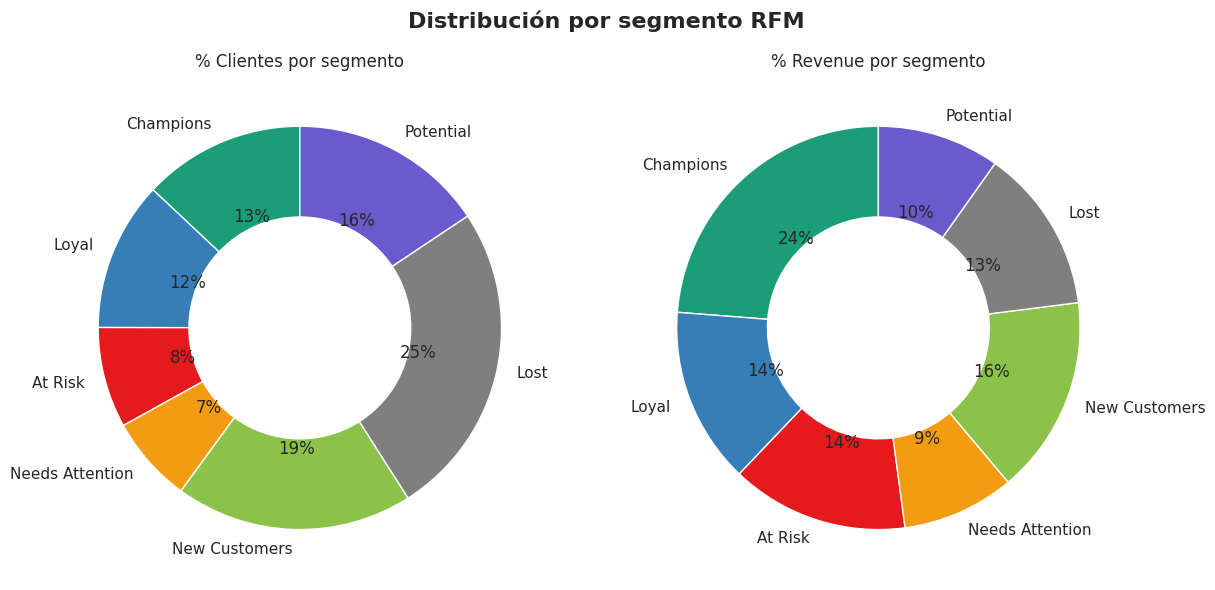

In [ ]:

# Distribución por segmento: % Clientes y % Revenue

# Este gráfico reproduce la lógica del archivo RFM_Analisis.pdf:
# izquierda = distribución de clientes por segmento
# derecha = distribución del revenue por segmento

colores_segmentos = {
    'Champions': '#1b9e77',
    'Loyal': '#377eb8',
    'Needs Attention': '#f39c12',
    'At Risk': '#e41a1c',
    'New Customers': '#8bc34a',
    'Lost': '#7f7f7f',
    'Potential': '#6a5acd'
}

# IMPORTANTE:
# resumen_rfm tiene los segmentos en el índice.
# Por eso primero convertimos el índice en una columna.
plot_rfm = resumen_rfm.copy()
plot_rfm.index.name = 'Segmento_RFM'
plot_rfm = plot_rfm.reset_index()

# Por seguridad, recalculamos los porcentajes si no existieran
if '% Clientes' not in plot_rfm.columns:
    plot_rfm['% Clientes'] = plot_rfm['Clientes'] / plot_rfm['Clientes'].sum() * 100

if '% Rev.' not in plot_rfm.columns:
    plot_rfm['% Rev.'] = plot_rfm['Revenue'] / plot_rfm['Revenue'].sum() * 100

# Quitamos segmentos sin clientes para evitar problemas visuales
plot_rfm = plot_rfm[plot_rfm['Clientes'] > 0].copy()

# Creamos figura con dos gráficos tipo dona
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Gráfico 1: % Clientes
axes[0].pie(
    plot_rfm['% Clientes'],
    labels=plot_rfm['Segmento_RFM'],
    autopct='%1.0f%%',
    startangle=90,
    colors=[colores_segmentos.get(seg, '#cccccc') for seg in plot_rfm['Segmento_RFM']],
    wedgeprops=dict(width=0.45)
)

axes[0].set_title('% Clientes por segmento')

# Gráfico 2: % Revenue
axes[1].pie(
    plot_rfm['% Rev.'],
    labels=plot_rfm['Segmento_RFM'],
    autopct='%1.0f%%',
    startangle=90,
    colors=[colores_segmentos.get(seg, '#cccccc') for seg in plot_rfm['Segmento_RFM']],
    wedgeprops=dict(width=0.45)
)

axes[1].set_title('% Revenue por segmento')

plt.suptitle('Distribución por segmento RFM', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

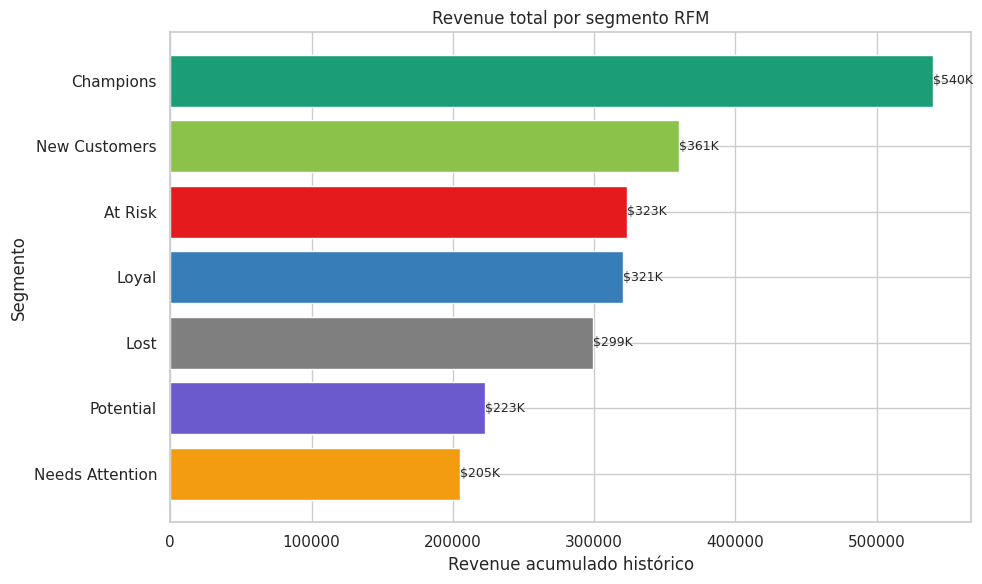

In [ ]:

# Revenue total por segmento

revenue_segmento = (
    resumen_rfm
    .sort_values('Revenue', ascending=True)
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.barh(
    revenue_segmento['Segmento_RFM'],
    revenue_segmento['Revenue'],
    color=[colores_segmentos.get(seg, '#cccccc') for seg in revenue_segmento['Segmento_RFM']]
)

plt.title('Revenue total por segmento RFM')
plt.xlabel('Revenue acumulado histórico')
plt.ylabel('Segmento')

# Etiquetas al final de cada barra
for i, valor in enumerate(revenue_segmento['Revenue']):
    plt.text(
        valor,
        i,
        f'${valor/1000:.0f}K',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

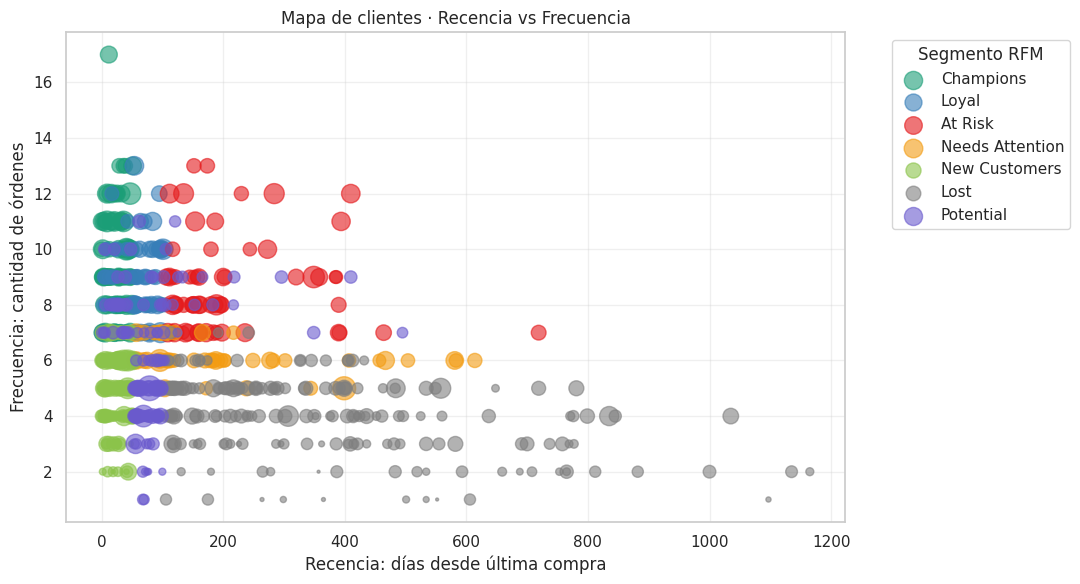

In [ ]:

# Mapa de clientes · Recencia vs Frecuencia


plt.figure(figsize=(11, 6))

for segmento in orden_segmentos:
    subset = rfm[rfm['Segmento_RFM'] == segmento]

    plt.scatter(
        subset['Recency'],
        subset['Frequency'],
        s=np.sqrt(subset['Monetary']) * 2,
        alpha=0.6,
        label=segmento,
        color=colores_segmentos.get(segmento, '#cccccc')
    )

plt.title('Mapa de clientes · Recencia vs Frecuencia')
plt.xlabel('Recencia: días desde última compra')
plt.ylabel('Frecuencia: cantidad de órdenes')
plt.legend(title='Segmento RFM', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Análisis RFM · Segmentación de clientes

El análisis RFM permite clasificar a los clientes a partir de tres dimensiones comerciales:

- **Recencia:** cantidad de días desde la última compra.
- **Frecuencia:** cantidad de órdenes realizadas por el cliente.
- **Monetario:** gasto total acumulado por cliente.

A cada dimensión se le asignó un puntaje del 1 al 5. En el caso de **Recency**, los clientes con compras más recientes reciben mayor puntaje. En **Frequency** y **Monetary**, los clientes con más órdenes y mayor gasto acumulado reciben mayor valoración.

A partir de la combinación de estos puntajes se construyeron siete segmentos:

- **Champions:** clientes recientes, frecuentes y de alto valor.
- **Loyal:** clientes con buena frecuencia y buen nivel de compra.
- **At Risk:** clientes valiosos que hace mucho tiempo no compran.
- **Needs Attention:** clientes que todavía tienen valor, pero muestran señales de enfriamiento.
- **New Customers:** clientes recientes que todavía deben ser desarrollados.
- **Lost:** clientes con baja actividad reciente y bajo valor actual.
- **Potential:** clientes intermedios con posibilidad de crecimiento.

Esta segmentación permite priorizar acciones comerciales de manera más precisa, ya que no todos los clientes requieren la misma estrategia.

## Conclusiones y acciones prioritarias

### At Risk: clientes valiosos que requieren acción urgente

El segmento **At Risk** representa clientes con buena frecuencia histórica y un valor monetario relevante, pero que llevan demasiado tiempo sin comprar. Esto los convierte en un grupo crítico para la empresa, porque existe revenue potencial en riesgo de perderse. La acción recomendada es diseñar campañas de reactivación urgentes, con beneficios personalizados, recordatorios comerciales o promociones específicas.

### Needs Attention: clientes que todavía pueden recuperarse

El segmento **Needs Attention** reúne clientes que no están completamente perdidos, pero muestran señales de debilitamiento en su relación con la empresa. Son clientes que requieren contacto proactivo antes de pasar al segmento Lost. Para este grupo conviene trabajar con ofertas personalizadas, recomendaciones de productos y comunicaciones orientadas a recuperar frecuencia de compra.

### Champions y Loyal: núcleo de valor del negocio

Los clientes **Champions** y **Loyal** son los más importantes para sostener el negocio. Compran con frecuencia, tienen buen valor acumulado y mantienen una relación activa con la empresa. La estrategia recomendada no debería centrarse solo en descuentos, sino en fidelización, acceso anticipado a productos, atención preferencial, programas de beneficios y acciones de upselling.

### New Customers: oportunidad de desarrollo

Los **New Customers** son clientes recientes que todavía no tienen una frecuencia alta ni un valor acumulado elevado. La prioridad es lograr una segunda compra y acompañarlos con un buen proceso de onboarding. Si se trabaja correctamente este grupo, puede convertirse en Loyal en el futuro.

### Lost: evaluar recuperación o baja prioridad

El segmento **Lost** reúne clientes con baja actividad y mucho tiempo sin comprar. En este caso, la empresa puede aplicar campañas de win-back, aunque también debería evaluar si el costo de recuperación justifica el esfuerzo comercial.

## 14. Primeros insights

Estos son hallazgos iniciales, todavía sujetos a una revisión final:

1. El dataset necesitaba limpieza real: tipos mal interpretados, fechas inválidas, valores corruptos, nulos y errores de tipeo.
2. `Postal Code` debía tratarse como texto, no como número. Esto es importante para no perder ceros a la izquierda y para evitar estadísticas sin sentido.
3. Las ventas están concentradas en algunas categorías y subcategorías, pero la rentabilidad no siempre acompaña el volumen vendido.
4. Hay subcategorías con ganancias negativas o bajas, que conviene revisar comercialmente.
5. Los descuentos parecen estar relacionados con pérdidas en algunas operaciones, por lo que sería útil analizar políticas de descuento.
6. La variable temporal permite armar un tablero con evolución mensual de ventas, profit y cantidad de órdenes.
7. Para Power BI o LOOKER STUDIO conviene trabajar con `df_sales_limpio_para_powerbi.csv` como base principal.

## 15. Posibles visualizaciones para Power BI


Para la presentación final se podrían armar estos gráficos:

- KPI de ventas totales, profit total, cantidad de órdenes y clientes únicos.
- Línea de ventas mensuales.
- Barras de ventas por categoría y subcategoría.
- Ranking de subcategorías con menor profit.
- Mapa o análisis geográfico por estado / región / código postal.
- Segmentación por tipo de cliente.
- Análisis de descuentos contra profit.

Esto ya deja el dataset preparado para pasar a la herramienta de visualización.